In [28]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [29]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be adjusted by the LLM
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be adjusted by the LLM
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration # NEW: Track when it was last improved

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance (unchanged)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS 
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0 # NEW
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration # NEW
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS 
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: ENHANCED LOCAL SEARCH 
# =========================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

# =========================================================================
# PART 5: ROBUST LLM AGENT AND MAIN EXECUTION FUNCTION (V5 - REFINED)
# =========================================================================

def extract_problem_features_for_llm():
    """
    NEW: Extract meaningful statistical features from the problem instance.
    This is the core of the "Strategist" model.
    """
    if capacities == NULL or weights == NULL or profits == NULL:
        return None

    # Calculate overall capacity tightness
    total_capacity = sum(capacities[i] for i in range(nf))
    total_avg_weight = sum(sum(weights[obj][i] for i in range(ni)) for obj in range(nf)) / nf
    capacity_tightness = total_avg_weight / total_capacity if total_capacity > 0 else 0

    # Calculate profit and weight variance for each objective
    profit_variances = []
    weight_variances = []
    for obj in range(nf):
        profits_list = [profits[obj][i] for i in range(ni)]
        weights_list = [weights[obj][i] for i in range(ni)]
        profit_variances.append(np.var(profits_list))
        weight_variances.append(np.var(weights_list))

    features = {
        "num_items": ni,
        "num_objectives": nf,
        "capacity_tightness": round(capacity_tightness, 4),
        "avg_profit_variance": round(np.mean(profit_variances), 2),
        "avg_weight_variance": round(np.mean(weight_variances), 2),
    }
    return features

cdef void write_results_to_file(pop *P, output_file, str log_message=""):
    """Write the Pareto front results and a log message to a file."""
    cdef int i, j
    
    with open(output_file if isinstance(output_file, str) else output_file.decode(), "a") as fpareto:
        if log_message:
            fpareto.write(f"# LOG: {log_message}\n")
        fpareto.write("\n")
        for i in range(P.size):
            for j in range(nf):
                fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
            fpareto.write("\n")

def run_efficient_llm_moacp_v5(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    REFINED: Run MOACP with a focused LLM "Strategist" Agent (V5).
    This version uses detailed problem features and structured JSON prompts.
    """
    # All cdef variables must be declared at the top of the function
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int it
    
    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # --- REFINED LLM Agent Definition (V5 - The Strategist) ---
    class LLMStrategistV5:
        def __init__(self, model_name="llama3:latest"): 
            self.model_name = model_name
            self.cache = {} 

        def _call_llm_with_json(self, prompt, cache_key):
            """Helper to call LLM and robustly parse JSON."""
            if cache_key in self.cache:
                print(f"  [LLM Cache Hit] Using cached response.")
                return self.cache[cache_key]
            
            print(f"  [LLM Call] Sending prompt to {self.model_name}...")
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt, format='json')
                response_text = response.get('response', '').strip()
                
                if not response_text:
                    print("  [LLM Error] Empty response. Using default strategy.")
                    return None

                result = json.loads(response_text)
                self.cache[cache_key] = result
                print(f"  [LLM Success] Received valid JSON.")
                return result

            except json.JSONDecodeError as e:
                print(f"  [LLM Error] Failed to decode JSON: {e}. Response was: '{response_text[:100]}...'")
                return None
            except Exception as e:
                print(f"  [LLM Error] An unexpected error occurred: {e}. Using default strategy.")
                return None

        def get_initial_strategy(self, problem_features):
            """Get one initial strategy based on detailed problem features."""
            cache_key = f"init_{hash(str(problem_features))}"
            
            prompt = f"""
You are an expert strategist for the Multi-Objective Knapsack Problem. Your task is to analyze the features of a problem instance and recommend the best initial search strategy.

The key parameter you control is 'L', which determines the number of items to try swapping during the local search. A higher L means a more aggressive, explorative search. A lower L means a more focused, exploitative search.

Here are the problem features:
{json.dumps(problem_features, indent=2)}

Based on these features, choose the best strategy.
- If the problem is 'tight' (high capacity_tightness) or has high variance, a more explorative approach might be better.
- If the problem is 'loose' or has low variance, a more focused approach might be better.

Respond with a JSON object containing 'strategy_name', 'L_value', and 'reasoning'.
Example: {{"strategy_name": "AGGRESSIVE", "L_value": 8, "reasoning": "High capacity tightness requires broad exploration."}}
"""
            result = self._call_llm_with_json(prompt, cache_key)
            
            if result and 'L_value' in result:
                print(f"  [LLM Decision] Strategy: {result.get('strategy_name')}, L: {result['L_value']}")
                print(f"  [LLM Reasoning] {result.get('reasoning')}")
                return result['L_value']
            return 5 # Default L value

    # --- Main Execution Loop ---
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    
    total_time = 0
    start_time = time.time()
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"\n--- RUN {run}/{NRUNS} ---")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        # --- LLM Integration ---
        llm_strategist = LLMStrategistV5() 
        problem_features = extract_problem_features_for_llm()
        
        print(f"  [Problem Features] {json.dumps(problem_features, indent=4)}")
        
        # --- LLM Call 1: Initial Strategy ---
        L = llm_strategist.get_initial_strategy(problem_features)
        # We will keep kappa fixed for now to isolate the effect of L.
        kappa = 0.05 
        
        print(f"  [Final Parameters] L={L}, kappa={kappa}")
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        current_log = f"Run {run}: Initial LLM strategy set L={L} based on features."

        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            Indicator_local_search1(solutions, archive, alpha)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        write_results_to_file(P, output_file, current_log)
        print(f"  [Run Summary] LLM calls this run: 1")
        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")


In [30]:
# =========================================================================
# PART 6: RUN THE EFFICIENT EXPERIMENTS (V4)
# =========================================================================

print("Running Efficient LLM-MOACP V4 on test instances...")
print("This version is optimized for efficiency with minimal LLM calls.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_efficient_llm_moacp_v5(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_Strategist_v5.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_efficient_llm_moacp_v5(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Strategist_v5.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_efficient_llm_moacp_v5(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Strategist_v5.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll efficient experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_Strategist_v5.txt")
print("- 5002_Results_Strategist_v5.txt")
print("- 7502_Results_Strategist_v5.txt")
print("\nYou can now run the analysis cells to compare the new results.")

Running Efficient LLM-MOACP V4 on test instances...
This version is optimized for efficiency with minimal LLM calls.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 745.59,
    "avg_weight_variance": 693.31
}
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Decision] Strategy: EXPLORE, L: 6
  [LLM Reasoning] Moderate capacity tightness and high variance in both profit and weight suggest a balance between exploration and exploitation. A value of L=6 provides a good trade-off between exploring the solution space and focusing on improving the current solution.
  [Final Parameters] L=6, kappa=0.05
  [Run Summary] LLM calls this run: 1

--- RUN 2/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,


Starting results analysis: Original Baseline vs. LLM-Strategist V5...

--- Analyzing 250-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 212
    Hypervolume: 6614986.88
  LLM-Strategist V5:
    Pareto Front Size: 201 (-5.19%)
    Hypervolume: 6739863.12 (+1.89%)


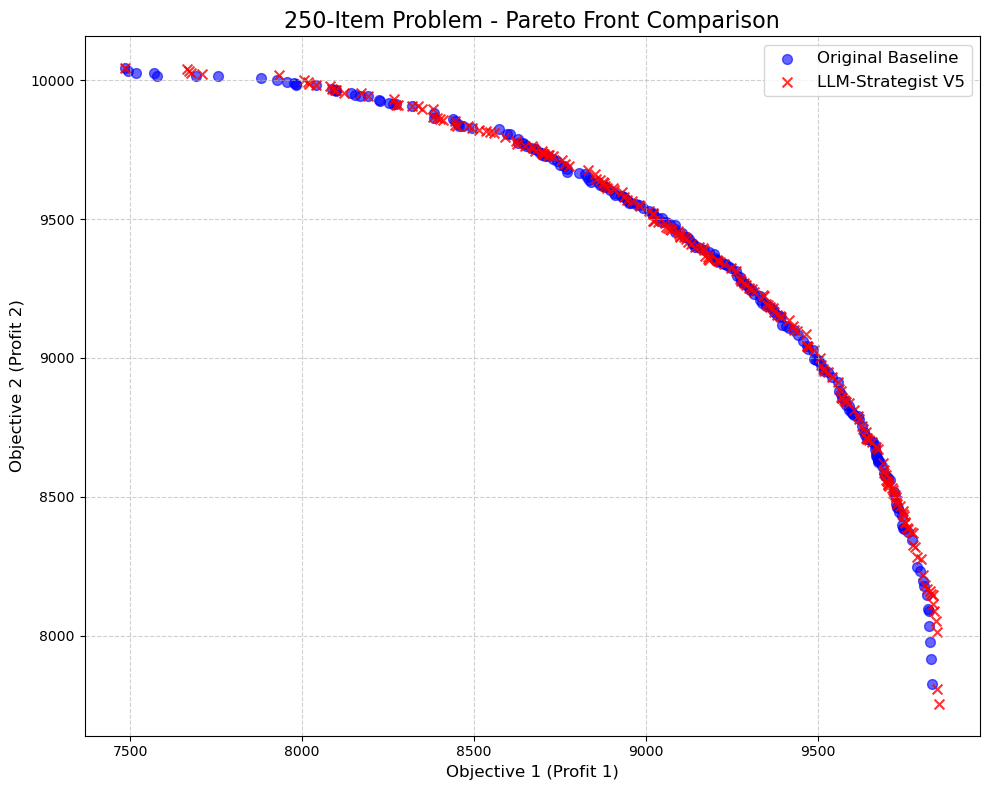


--- Analyzing 500-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 369
    Hypervolume: 23044962.94
  LLM-Strategist V5:
    Pareto Front Size: 307 (-16.80%)
    Hypervolume: 23636230.89 (+2.57%)


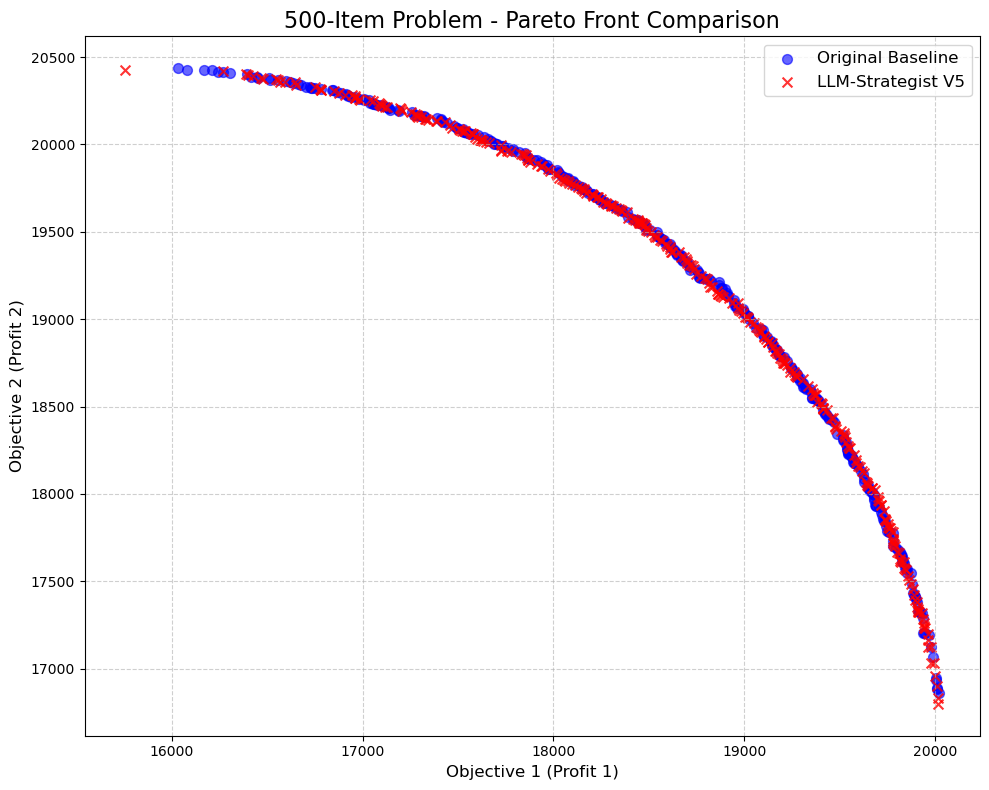


--- Analyzing 750-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 552
    Hypervolume: 56877706.67
  LLM-Strategist V5:
    Pareto Front Size: 514 (-6.88%)
    Hypervolume: 57494423.50 (+1.08%)


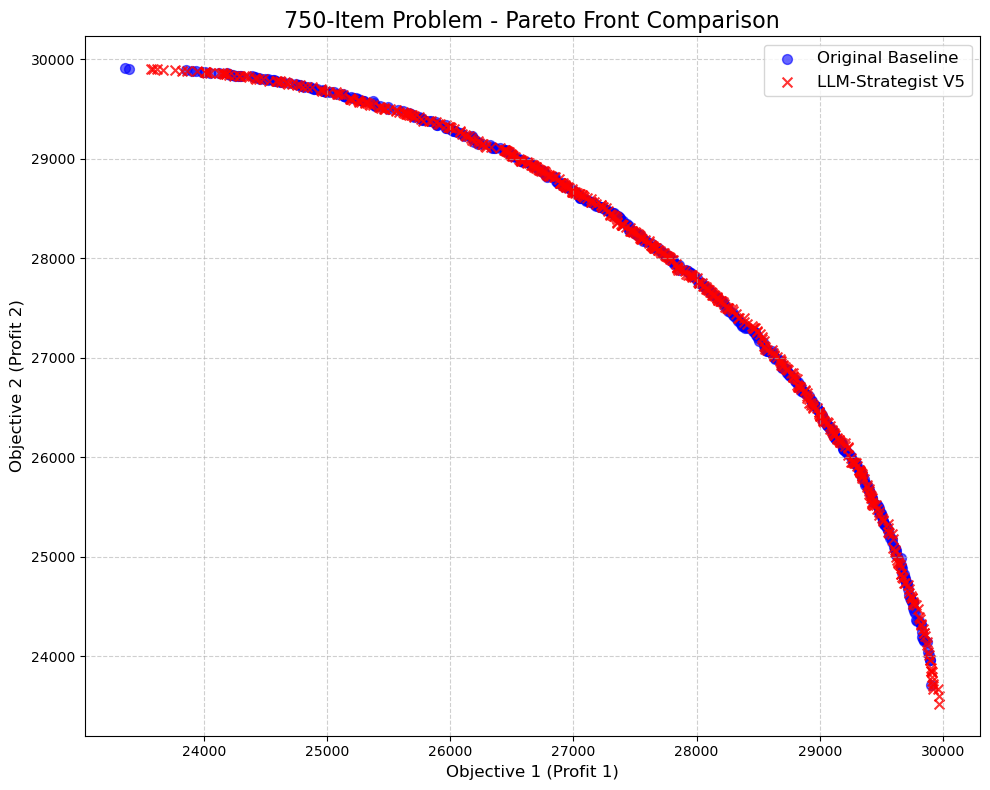


              SUMMARY OF IMPROVEMENTS

250-Item Problem:
  Hypervolume Improvement: +1.89%

500-Item Problem:
  Hypervolume Improvement: +2.57%

750-Item Problem:
  Hypervolume Improvement: +1.08%

--------------------------------------------------
  AVERAGE HV IMPROVEMENT: +1.85%
--------------------------------------------------

Analysis complete.


In [31]:
# =========================================================================
# PART 7: RESULTS COMPARISON AND ANALYSIS (Fixed for V5)
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    # Find a reference point that is slightly worse than the worst point in all objectives
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    # Sort points by the first objective to calculate the area under the curve
    sorted_points = sorted(points, key=lambda p: p[0])
    
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        # Area of the rectangle between two points on the front
        hv += (x2 - x1) * (ref_y - y1)
    
    # Add the area of the last rectangle to the reference point
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_baseline_vs_strategist(original_file, strategist_v5_file, title):
    """
    Compare the original baseline results with the new LLM-Strategist V5 results.
    """
    print(f"\n--- Analyzing {title} ---")
    
    # --- Load and Process Original Results ---
    original_points = []
    try:
        with open(original_file, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    try:
                        original_points.append([float(x) for x in line.split()])
                    except ValueError:
                        pass # Skip malformed lines
    except FileNotFoundError:
        print(f"  [ERROR] Original file not found: {original_file}")
        return None

    # --- Load and Process Strategist V5 Results ---
    strategist_v5_points = []
    try:
        with open(strategist_v5_file, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    try:
                        strategist_v5_points.append([float(x) for x in line.split()])
                    except ValueError:
                        pass # Skip malformed lines
    except FileNotFoundError:
        print(f"  [ERROR] Strategist V5 file not found: {strategist_v5_file}")
        return None

    # --- Calculate Pareto Fronts and Metrics ---
    original_pareto = get_true_pareto_front(original_points)
    strategist_v5_pareto = get_true_pareto_front(strategist_v5_points)
    
    original_size = len(original_pareto)
    strategist_v5_size = len(strategist_v5_pareto)
    
    original_hv = calculate_hypervolume(original_pareto)
    strategist_v5_hv = calculate_hypervolume(strategist_v5_pareto)
    
    # --- Calculate Percentage Improvements ---
    size_improvement = (strategist_v5_size - original_size) / original_size * 100 if original_size > 0 else 0
    hv_improvement = (strategist_v5_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    # --- Print Results ---
    print(f"  Original Algorithm:")
    print(f"    Pareto Front Size: {original_size}")
    print(f"    Hypervolume: {original_hv:.2f}")
    print(f"  LLM-Strategist V5:")
    print(f"    Pareto Front Size: {strategist_v5_size} ({size_improvement:+.2f}%)")
    print(f"    Hypervolume: {strategist_v5_hv:.2f} ({hv_improvement:+.2f}%)")
    
    # --- Plotting ---
    plt.figure(figsize=(10, 8))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Baseline")
    if strategist_v5_pareto:
        sx, sy = zip(*strategist_v5_pareto)
        plt.scatter(sx, sy, color='red', marker='x', s=50, alpha=0.8, label="LLM-Strategist V5")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "title": title,
        "original_size": original_size,
        "strategist_v5_size": strategist_v5_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "strategist_v5_hv": strategist_v5_hv,
        "hv_improvement": hv_improvement
    }

# --- MAIN EXECUTION ---
print("Starting results analysis: Original Baseline vs. LLM-Strategist V5...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "2502_ResultsMD.txt",
        "strategist": "2502_Results_Strategist_v5.txt",
        "title": "250-Item Problem"
    },
    {
        "original": "5002_ResultsMD.txt",
        "strategist": "5002_Results_Strategist_v5.txt",
        "title": "500-Item Problem"
    },
    {
        "original": "7502_ResultsMD.txt",
        "strategist": "7502_Results_Strategist_v5.txt",
        "title": "750-Item Problem"
    }
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_strategist(
        files["original"], 
        files["strategist"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*50)
print("              SUMMARY OF IMPROVEMENTS")
print("="*50)

if all_results:
    total_hv_improvement = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        total_hv_improvement += res['hv_improvement']

    avg_hv_improvement = total_hv_improvement / len(all_results)
    
    print("\n" + "-"*50)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print("-"*50)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")

In [15]:
# Simple test to see if the module exists and can be imported
try:
    import optimized_moacp_cython
    print("✅ Module imported successfully.")
    print("Functions available:", dir(optimized_moacp_cython))
except ImportError as e:
    print(f"❌ ImportError: {e}")
except Exception as e:
    print(f"❌ Other error: {e}")

✅ Module imported successfully.
Functions available: ['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [10]:
import optimized_moacp_cython as omc
print(dir(omc))

['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [16]:
import optimized_moacp_cython as omc

for fn in [
    "set_alpha", "set_kappa", "set_L", "set_smallValue",
    "set_mutation_rate", "set_local_search_intensity",
    "set_greedy_bias", "set_repair_aggressiveness"
]:
    print(fn, hasattr(omc, fn))

set_alpha True
set_kappa True
set_L True
set_smallValue True
set_mutation_rate False
set_local_search_intensity False
set_greedy_bias False
set_repair_aggressiveness False
